In [4]:
from biosteam import main_flowsheet as F
import biosteam as bst
import thermosteam as tmo
import pandas as pd
import numpy as np
bst.nbtutorial()


from lignin_saf.ligsaf_chemicals import create_chemicals
from lignin_saf.ligsaf_settings import feed_parameters, prices
from lignin_saf.systems.rcf import create_rcf_system
from lignin_saf.systems.rcf_oil_purification import create_rcf_oil_purification_system
from lignin_saf.systems.monomer_purification import create_monomer_purification_system
from lignin_saf.systems.ligsaf_utilities import create_rcf_utilities_system
from lignin_saf.systems.hdo import create_hdo_system


chems = create_chemicals()
bst.settings.set_thermo(chems)
bst.settings.CEPCI = 541.7   # 2016 USD basis

# Poplar group must be defined before creating any stream that references it
chems.define_group(
    name='Poplar',
    IDs=['Glucan', 'Xylan', 'Arabinan', 'Mannan', 'Galactan',
         'Sucrose', 'Lignin', 'Acetate', 'Extract', 'Ash'],
    composition=[0.464, 0.134, 0.002, 0.037, 0.014,
                 0.001, 0.285, 0.035, 0.016, 0.012],
    wt=True
)

poplar_in = bst.Stream('Poplar_In',
                       Poplar=feed_parameters['flow'] * 1e3,
                       Water=feed_parameters['moisture'] * feed_parameters['flow'] * 1e3,
                       phase='l', units='kg/d', price=prices['Feedstock'])

# ── Area 200: RCF process ──────────────────────────────────────────────────
rcf_system = create_rcf_system(ins=poplar_in)
rcf_system.simulate()

# ── Area 300: Purification ─────────────────────────────────────────────────
rcf_oil_purification_sys = create_rcf_oil_purification_system(ins=F.RCF_Oil)
monomer_purification_sys = create_monomer_purification_system(ins=F.Purified_RCF_Oil)
rcf_oil_purification_sys.simulate()
monomer_purification_sys.simulate()
BT, WWT, gas_mixer = create_rcf_utilities_system()


# ── Area 400: Hydrodeoxygenation ───────────────────────────────────────────
hdo_system = create_hdo_system(ins=F.RCF_Monomers)
hdo_system.simulate()

# Route HDO purge gases to BT gas combustion
gas_mixer.ins.append(F.HDO_purge_gases)


# Route HDO wastewater streams to WWT inlet mixer
F.unit.M601.ins.extend([F.HDO_wash_water, F.HDO_WW])
# Sludge from WWT is already connected to BT in this system. 
# For rcf_etoh script, a solids_to_BT mixer is needed because ethanol system adds a second combustible stream (filter cake from S401.outs[0])
# Since BT.ins[0] (solid intake stream for BT) only has 1 input, a mixer is needed in rcf integrated with cellulosic ethanol systems


rcf_hdo_system = bst.System(
    'Combined_RCF_System',
    path=(rcf_system, rcf_oil_purification_sys, monomer_purification_sys, hdo_system, WWT),
    facilities=[gas_mixer, BT],
)

rcf_hdo_system.simulate()


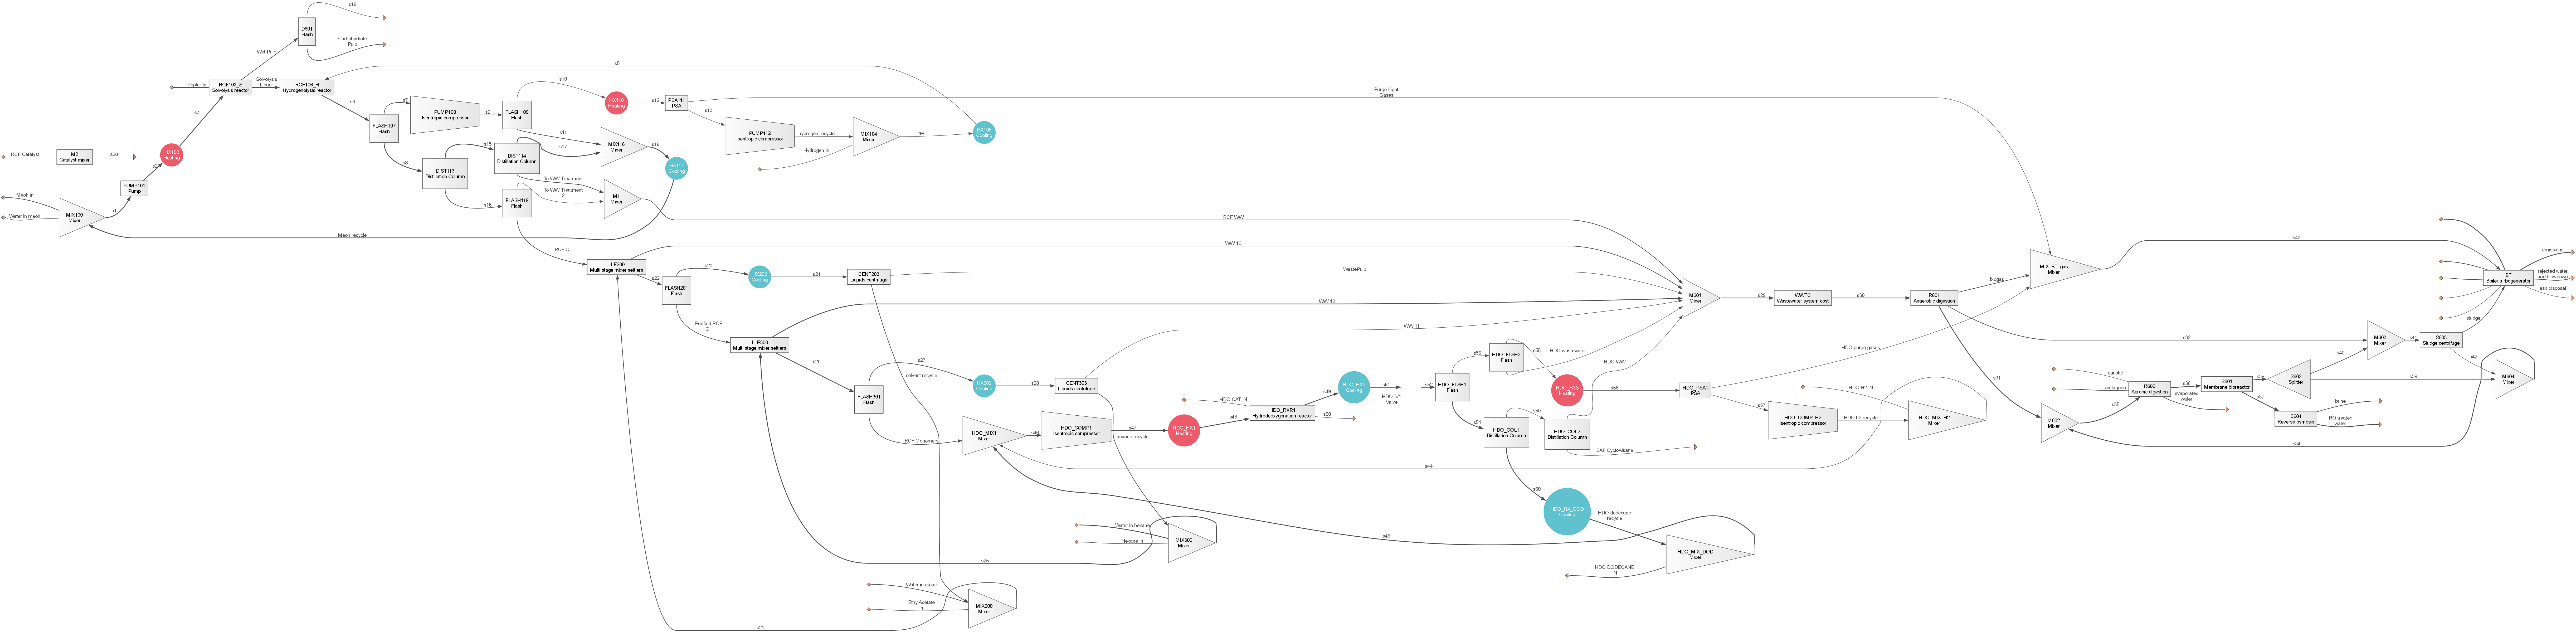

In [6]:
rcf_hdo_system.diagram(format = 'png')